In [1]:
!pip install numpy
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
grid_size = 5

goal_state = (4,4)

actions = {
    0: (-1,0),
    1: (1,0),
    2: (0,-1),
    3: (0,1)
}

num_actions = len(actions)

In [4]:
def step(state, action):

    next_state = (
        state[0] + actions[action][0],
        state[1] + actions[action][1]
    )

    if next_state[0] < 0 or next_state[0] >= grid_size:
        next_state = state

    if next_state[1] < 0 or next_state[1] >= grid_size:
        next_state = state

    if next_state == goal_state:
        reward = 10
    else:
        reward = -1

    return next_state, reward

In [5]:
V = np.zeros((grid_size, grid_size))

print(V)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [6]:
alpha = 0.1

gamma = 0.9

epsilon = 0.1

episodes = 500

In [7]:
def choose_action():

    if np.random.rand() < epsilon:

        return np.random.randint(num_actions)

    else:

        return np.random.randint(num_actions)

In [8]:
episode_rewards = []

for episode in range(episodes):

    state = (0,0)

    total_reward = 0

    done = False

    while not done:

        action = choose_action()

        next_state, reward = step(state, action)

        td_target = reward + gamma * V[next_state]

        td_error = td_target - V[state]

        V[state] = V[state] + alpha * td_error

        state = next_state

        total_reward += reward

        if state == goal_state:
            done = True

    episode_rewards.append(total_reward)

print("TD Learning Complete")

TD Learning Complete


In [9]:
print("Learned State Values:")

print(np.round(V,2))

Learned State Values:
[[-9.49 -9.34 -9.08 -8.74 -8.52]
 [-9.39 -9.16 -8.75 -8.3  -7.79]
 [-9.21 -8.68 -8.05 -6.79 -6.02]
 [-8.83 -8.41 -7.1  -4.18  0.57]
 [-8.67 -8.12 -5.43  0.02  0.  ]]


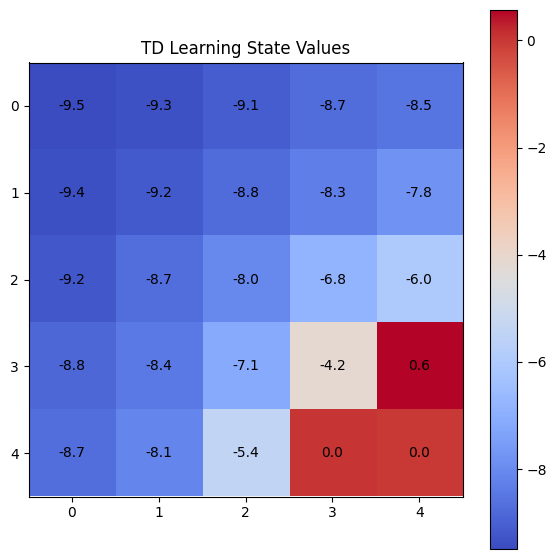

In [10]:
plt.figure(figsize=(7,7))

plt.imshow(V, cmap='coolwarm')

for i in range(grid_size):

    for j in range(grid_size):

        plt.text(
            j,
            i,
            round(V[i,j],1),
            ha='center',
            va='center',
            color='black'
        )

plt.colorbar()

plt.title("TD Learning State Values")

plt.show()

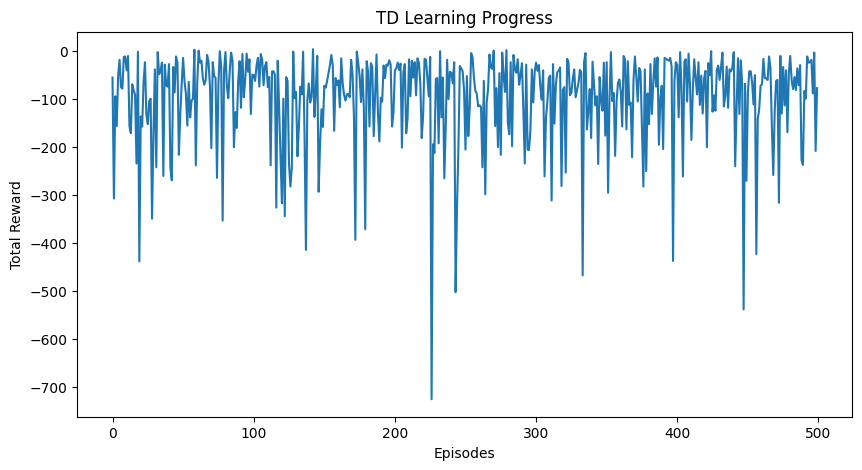

In [11]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.xlabel("Episodes")

plt.ylabel("Total Reward")

plt.title("TD Learning Progress")

plt.show()